In [ ]:
0 - Bibliotecas e carga de dados

In [5]:
# Importando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)


# Carregando arquivos Parquet

DADOS_DIR = Path("../dados/consolidados")

#print(DADOS_DIR.resolve())
#print(list(DADOS_DIR.iterdir()))

mshl = pd.read_parquet(DADOS_DIR / "MSHL_consolidado.parquet")
cnes_lt = pd.read_parquet(DADOS_DIR / "LT_consolidado.parquet")
sih_rd = pd.read_parquet(DADOS_DIR / "RD_consolidado.parquet")

#Verificar se carregou corretamente
print("MSHL:", mshl.shape)
print("CNES-LT:", cnes_lt.shape)
print("SIH-RD:", sih_rd.shape)


MSHL: (2673, 9)
CNES-LT: (13079, 8)
SIH-RD: (696841, 20)


1. Analisando as Competências

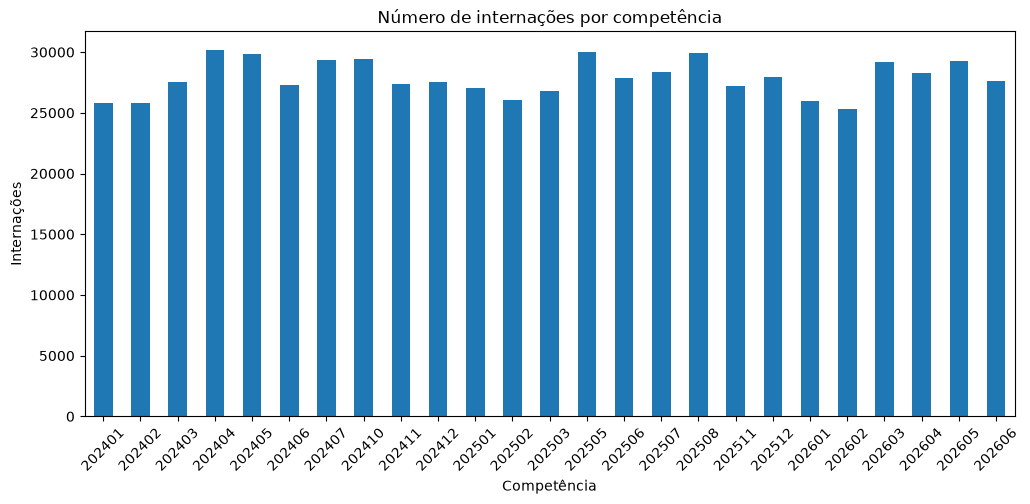

In [7]:
sih_rd["COMPETEN"].value_counts().sort_index()

sih_rd["COMPETEN"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Número de internações por competência")
plt.xlabel("Competência")
plt.ylabel("Internações")
plt.xticks(rotation=45)
plt.show()

2. Internações por unidade

In [8]:
internacoes_cnes = (
    sih_rd.groupby("CNES")
    .agg(
        internacoes=("N_AIH", "nunique"),
        registros=("N_AIH", "size"),
        dias_permanencia=("DIAS_PERM", "sum"),
        permanencia_media=("DIAS_PERM", "mean"),
        permanencia_mediana=("DIAS_PERM", "median")
    )
    .reset_index()
    .sort_values("internacoes", ascending=False)
)

internacoes_cnes.head(20)

,CNES,internacoes,registros,dias_permanencia,permanencia_media,permanencia_mediana
3,0000434,107582,107582,488569,4.54,2.00
8,0000655,66804,66804,514293,7.70,6.00
2,0000426,48867,48867,335925,6.87,3.00
0,0000396,44583,44583,165976,3.72,2.00
29,2802783,39456,39456,302509,7.67,4.00
4,0000477,37831,37831,155345,4.11,2.00
1,0000418,37663,37663,243781,6.47,3.00
23,2427427,36059,36059,203840,5.65,3.00
7,0000582,34394,34404,161503,4.69,2.00
6,0000566,24280,24280,100799,4.15,2.00


3. Internações por município

In [11]:
# 1. Agrupa e conta o número de internações únicas por município
demanda_municipal = (
    sih_rd.groupby("MUNIC_RES")["N_AIH"]
    .nunique()
    .reset_index(name="internacoes")
)

# 2. Calcula o valor percentual (em relação ao total geral do dataset)
total_geral = sih_rd["N_AIH"].nunique()
demanda_municipal["percentual"] = (demanda_municipal["internacoes"] / total_geral) * 100

# 3. Ordena e exibe o Top 20
demanda_municipal = demanda_municipal.sort_values("internacoes", ascending=False)
demanda_municipal.head(20)

,MUNIC_RES,internacoes,percentual
617,261160,229218,33.00
573,260790,68216,9.82
596,260960,42951,6.18
607,261070,32567,4.69
522,260345,19702,2.84
516,260290,16711,2.41
641,261370,13151,1.89
560,260680,11929,1.72
669,261640,10569,1.52
486,260005,9802,1.41


4. Perfil dos pacientes

Idade:

In [14]:
sih_rd["IDADE"].describe()

count   696,841.00
mean         41.20
std          24.25
min           0.00
25%          22.00
50%          41.00
75%          61.00
max          99.00
Name: IDADE, dtype: Float64

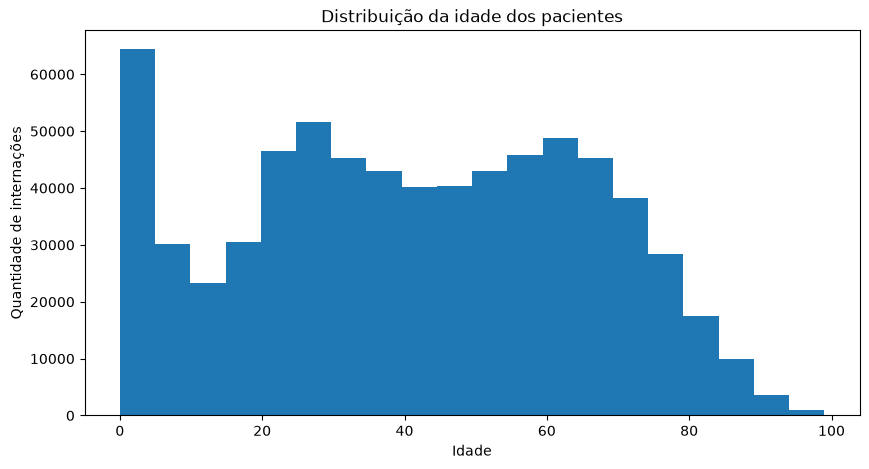

In [ ]:
sih_rd["IDADE"].plot(
    kind="hist",
    bins=20,
    figsize=(10, 5)
)

plt.title("Distribuição da idade dos pacientes")
plt.xlabel("Idade")
plt.ylabel("Quantidade de internações")
plt.show()

Sexo:

In [15]:
sih_rd["SEXO"].value_counts(dropna=False)

SEXO
3    393444
1    303397
Name: count, dtype: int64[pyarrow]

In [18]:
sih_rd["SEXO"].value_counts(normalize=True, dropna=False) * 100

SEXO
3   56.46
1   43.54
Name: proportion, dtype: double[pyarrow]

Óbitos:

In [19]:
sih_rd["MORTE"].value_counts(dropna=False)

MORTE
0    666137
1     30704
Name: count, dtype: int64[pyarrow]

In [20]:
sih_rd["MORTE"].value_counts(normalize=True, dropna=False) * 100

MORTE
0   95.59
1    4.41
Name: proportion, dtype: double[pyarrow]